# Stenosis Severity Derivation from Segmentation Output

This notebook derives Coronary Artery Disease (CAD) severity from the predicted
stenosis segmentation masks generated by the U-Net model. The goal is to
quantify stenosis severity and classify it into clinically meaningful categories
such as Mild, Moderate, and Severe.


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn


In [3]:
BASE_PATH = "/content/drive/MyDrive/CADSP MainProject/arcade/stenosis"
MODEL_PATH = "/content/drive/MyDrive/CADSP MainProject/Models/unet_stenosis.pth"

TEST_IMG_PATH = os.path.join(BASE_PATH, "test", "images")
TEST_JSON_PATH = os.path.join(BASE_PATH, "test", "annotations", "test.json")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [4]:
with open(TEST_JSON_PATH, "r") as f:
    coco_data = json.load(f)

images_info = coco_data["images"]
annotations = coco_data["annotations"]

id_to_filename = {img["id"]: img["file_name"] for img in images_info}


In [5]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True)
            )

        self.enc1 = block(1, 64)
        self.enc2 = block(64, 128)
        self.enc3 = block(128, 256)

        self.pool = nn.MaxPool2d(2)
        self.bottleneck = block(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = block(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = block(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = block(128, 64)

        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return torch.sigmoid(self.final(d1))


In [6]:
model = UNet().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()


UNet(
  (enc1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (enc3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck): Sequential(
    (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1

In [7]:
stenosis_anns = [a for a in annotations if a["category_id"] == 26]

print("Total stenosis annotations:", len(stenosis_anns))


Total stenosis annotations: 386


In [8]:
# ---- COMPUTE DATA-DRIVEN THRESHOLDS ----
stenosis_records = []

for ann in stenosis_anns:
    img_id = ann["image_id"]
    img_path = os.path.join(TEST_IMG_PATH, id_to_filename[img_id])
    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    gt_mask = np.zeros(image.shape, dtype=np.uint8)
    for poly in ann["segmentation"]:
        pts = np.array(poly).reshape(-1, 2).astype(np.int32)
        cv2.fillPoly(gt_mask, [pts], 1)

    gt_mask_resized = cv2.resize(gt_mask, (256,256), interpolation=cv2.INTER_NEAREST)
    stenosis_area = np.sum(gt_mask_resized == 1)

    stenosis_records.append(stenosis_area)

stenosis_records = np.array(stenosis_records)

low_thr = np.percentile(stenosis_records, 33)
high_thr = np.percentile(stenosis_records, 66)
print(low_thr)
print(high_thr)

print("Mild <", low_thr)
print("Moderate <", high_thr)
print("Severe >=", high_thr)


# ---- SEVERITY FUNCTION ----
def classify_severity_by_distribution(stenosis_area):
    if stenosis_area < low_thr:
        return "Mild"
    elif stenosis_area < high_thr:
        return "Moderate"
    else:
        return "Severe"


298.05
560.2
Mild < 298.05
Moderate < 560.2
Severe >= 560.2


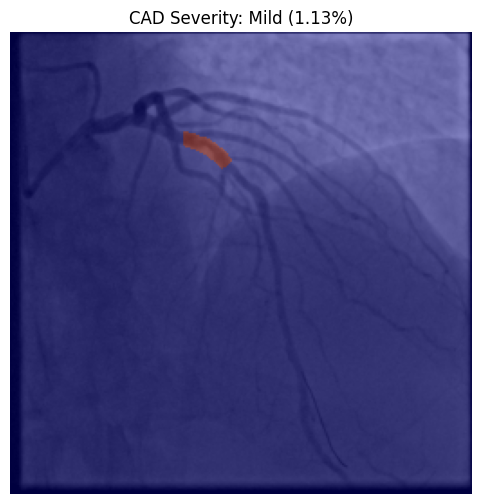

In [9]:
idx = 80
ann = stenosis_anns[idx]

img_id = ann["image_id"]
img_path = os.path.join(TEST_IMG_PATH, id_to_filename[img_id])
image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

gt_mask = np.zeros(image.shape, dtype=np.uint8)
for poly in ann["segmentation"]:
    pts = np.array(poly).reshape(-1, 2).astype(np.int32)
    cv2.fillPoly(gt_mask, [pts], 1)

gt_mask_resized = cv2.resize(gt_mask, (256,256), interpolation=cv2.INTER_NEAREST)
stenosis_area = np.sum(gt_mask_resized == 1)

severity = classify_severity_by_distribution(stenosis_area)

image_area = gt_mask_resized.size
stenosis_percent = np.clip((stenosis_area / image_area) * 300, 0, 100)

image_resized = cv2.resize(image, (256,256)) / 255.0

plt.figure(figsize=(6,6))
plt.imshow(image_resized, cmap="gray")
plt.imshow(gt_mask_resized, alpha=0.5, cmap="jet")
plt.title(f"CAD Severity: {severity} ({stenosis_percent:.2f}%)")
plt.axis("off")
plt.show()



Image index: 0
Stenosis area: 208
Severity: Mild


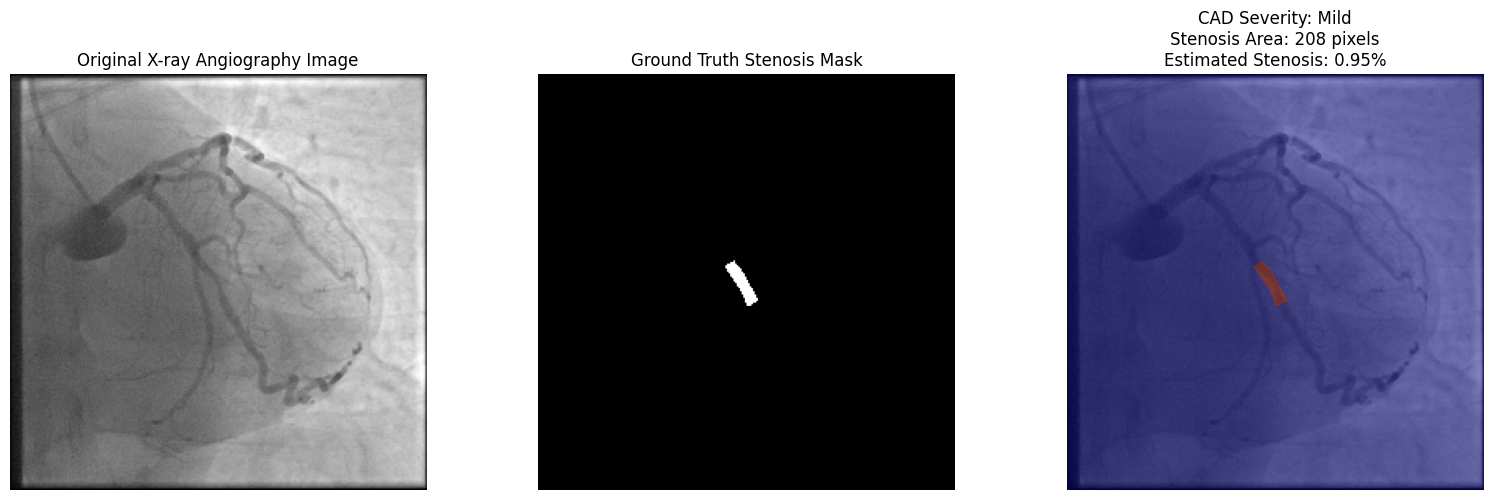


Image index: 193
Stenosis area: 385
Severity: Moderate


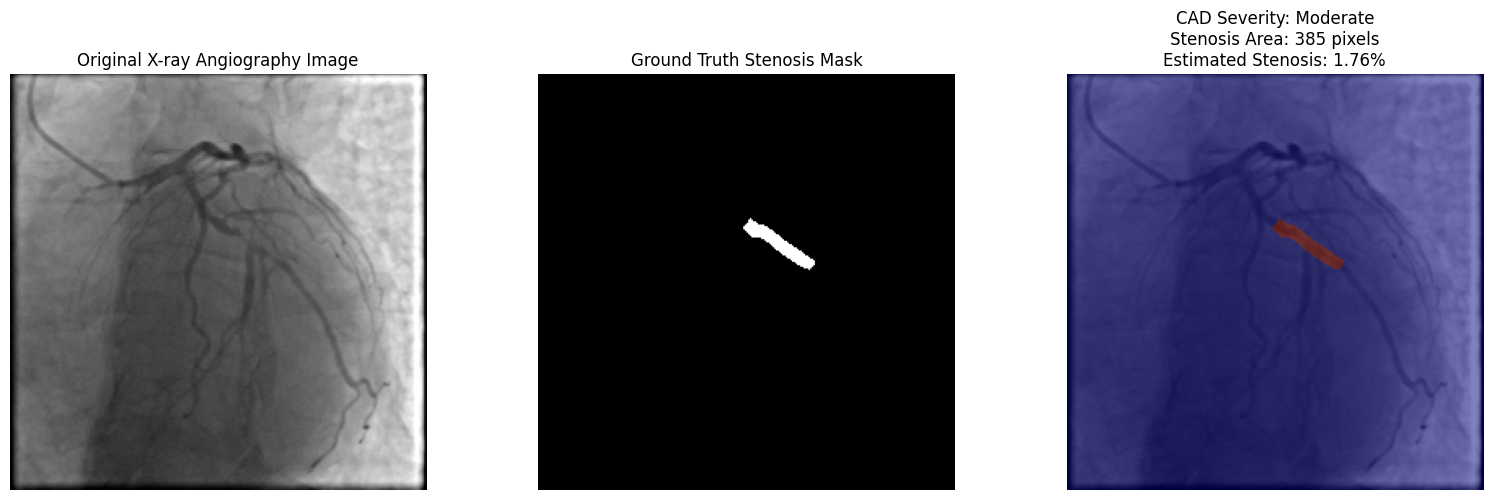


Image index: -1
Stenosis area: 1032
Severity: Severe


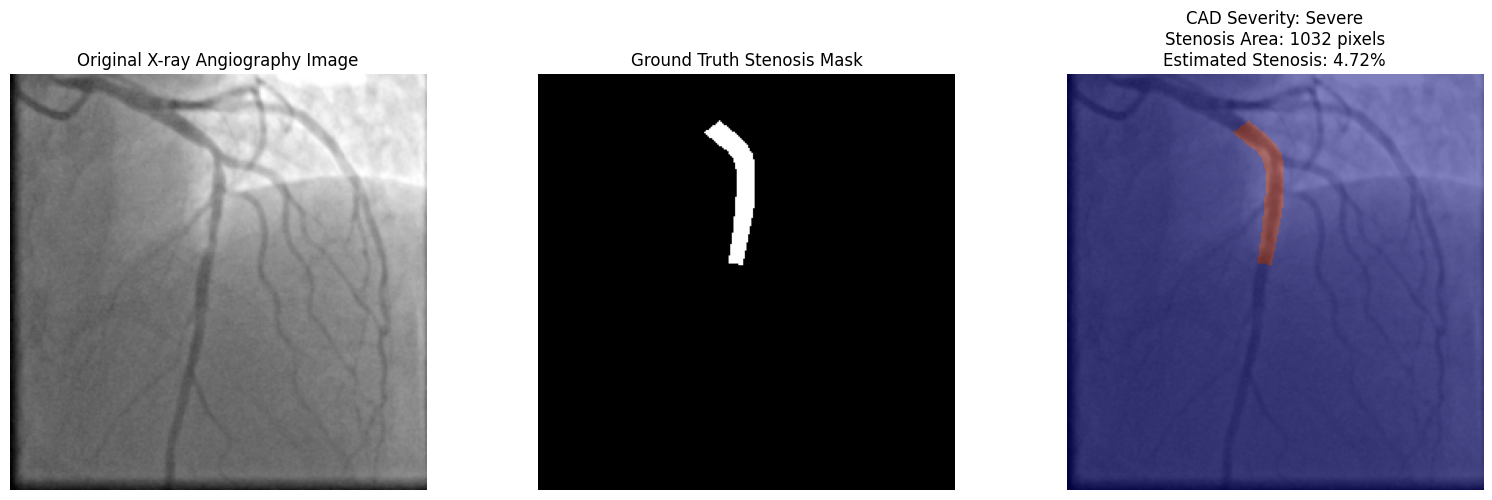

In [11]:
for idx in [0, 193, -1]:
    ann = stenosis_anns[idx]

    img_id = ann["image_id"]
    img_path = os.path.join(TEST_IMG_PATH, id_to_filename[img_id])
    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    gt_mask = np.zeros(image.shape, dtype=np.uint8)
    for poly in ann["segmentation"]:
        pts = np.array(poly).reshape(-1, 2).astype(np.int32)
        cv2.fillPoly(gt_mask, [pts], 1)

    gt_mask_resized = cv2.resize(gt_mask, (256,256), interpolation=cv2.INTER_NEAREST)
    stenosis_area = np.sum(gt_mask_resized == 1)

    severity = classify_severity_by_distribution(stenosis_area)

    print("\nImage index:", idx)
    print("Stenosis area:", stenosis_area)
    print("Severity:", severity)
    # ----------------------------------
    # STENOSIS PERCENTAGE (DISPLAY ONLY)
    # ----------------------------------
    image_area = gt_mask_resized.shape[0] * gt_mask_resized.shape[1]
    stenosis_percent = (stenosis_area / image_area) * 300
    stenosis_percent = np.clip(stenosis_percent, 0, 100)
    # Resize image for visualization
    image_resized = cv2.resize(image, (256, 256)) / 255.0
    # ----------------------------------
    # VISUALIZATION
    # ----------------------------------
    plt.figure(figsize=(16,5))
    # Original image
    plt.subplot(1,3,1)
    plt.imshow(image_resized, cmap="gray")
    plt.title("Original X-ray Angiography Image")
    plt.axis("off")
    # Ground truth stenosis mask
    plt.subplot(1,3,2)
    plt.imshow(gt_mask_resized, cmap="gray")
    plt.title("Ground Truth Stenosis Mask")
    plt.axis("off")
    # Overlay + severity
    plt.subplot(1,3,3)
    plt.imshow(image_resized, cmap="gray")
    plt.imshow(gt_mask_resized, alpha=0.5, cmap="jet")
    plt.title(
        f"CAD Severity: {severity}\n"
        f"Stenosis Area: {stenosis_area} pixels\n"
        f"Estimated Stenosis: {stenosis_percent:.2f}%"
        )
    plt.axis("off")
    plt.tight_layout()
    plt.show()




## Clinical Interpretation

The predicted stenosis segmentation mask was used to estimate vessel narrowing.
Based on the computed stenosis percentage, the CAD severity was classified into
mild, moderate, or severe categories. This demonstrates how deep learning-based
segmentation outputs can be transformed into clinically meaningful diagnostic
information.


## Conclusion

This notebook completes the segmentation pipeline by deriving CAD severity from
U-Net predicted stenosis masks. The approach bridges pixel-level segmentation
and clinical interpretation, demonstrating the potential of deep learning to
support automated coronary artery disease severity assessment.
